In [1]:
import pandas as pd
import sqlite3
import scipy.stats as stats
from scipy.stats import normaltest, skew ,  ttest_ind ,  mannwhitneyu
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [3]:
conn_second = sqlite3.connect("basketball.db")
conn_main = sqlite3.connect("basketball_reference.db")

df_seasons = pd.read_sql_query("SELECT * FROM seasons", conn_second)
df_team_stats = pd.read_sql_query("SELECT * FROM team_stats", conn_second)

df_seasons.to_sql("seasons", conn_main, if_exists="replace", index=False)
df_team_stats.to_sql("team_stats", conn_main, if_exists="replace", index=False)

conn_second.close()
conn_main.close()

In [4]:
conn = sqlite3.connect("basketball_reference.db")

tables = [
    "seasons", "teams", "team_stats", "players", "player_position", 
    "coaches", "awards", "award_season", "player_stats", "coach_stats"
]
dfs = {}
for table in tables:
    dfs[table] = pd.read_sql_query(f"SELECT * FROM {table};", conn)

In [5]:
def plot_numeric_distributions(df, name):
    numeric_cols = []

    for col in df.columns:
        dtype_name = df[col].dtype.name
        if "int" in dtype_name or "float" in dtype_name:
            numeric_cols.append(col)

    for col in numeric_cols:
        plt.figure(figsize=(6,4))

        df[col].dropna().hist(bins=50)

        mean = df[col].mean()
        median = df[col].median()

        plt.axvline(mean, color="red", linestyle="--", label="Mean")
        plt.axvline(median, color="green", linestyle="--", label="Median")

        plt.title(f"{name} - {col}")
        plt.legend()
        plt.show()

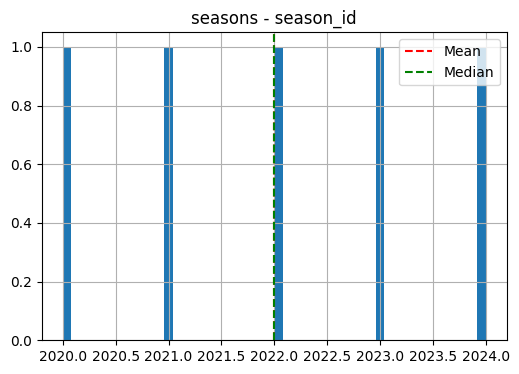

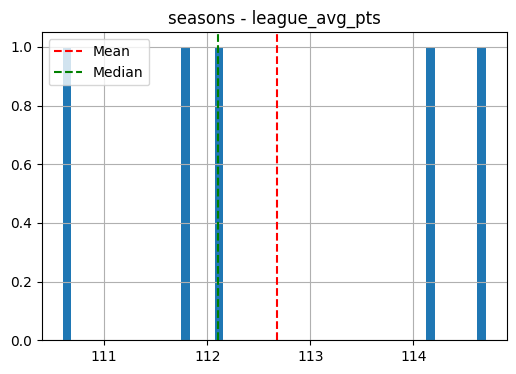

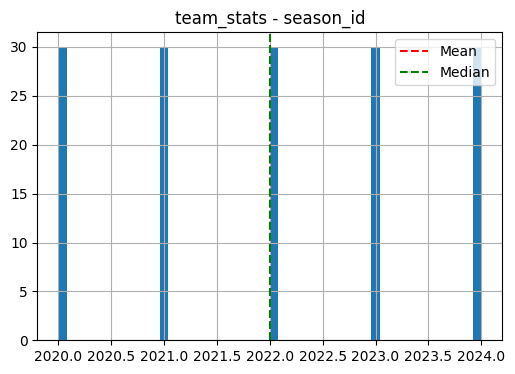

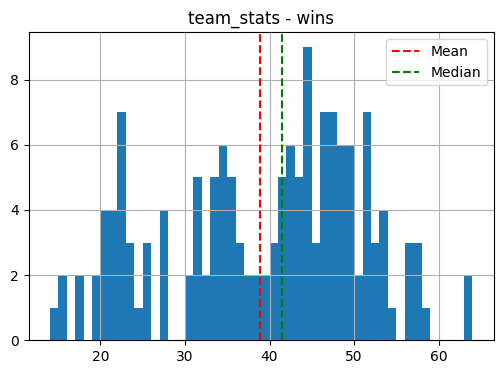

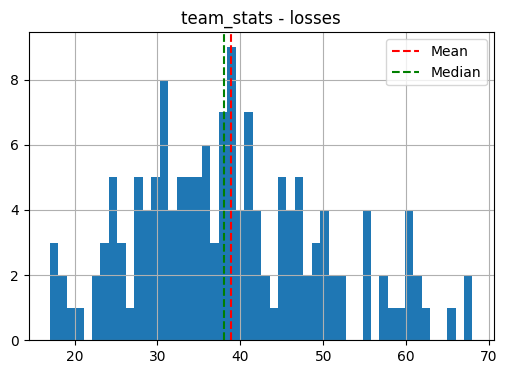

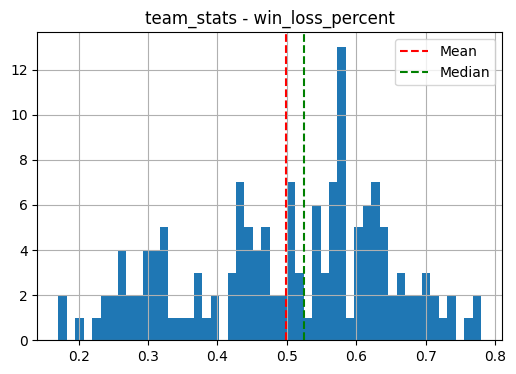

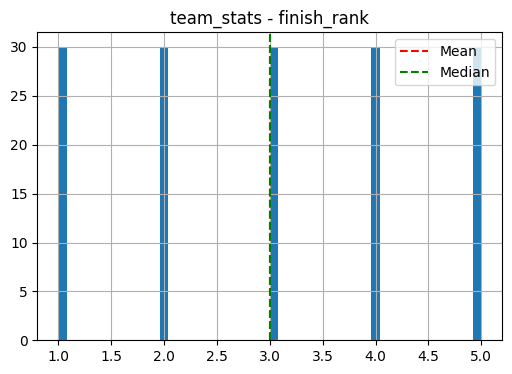

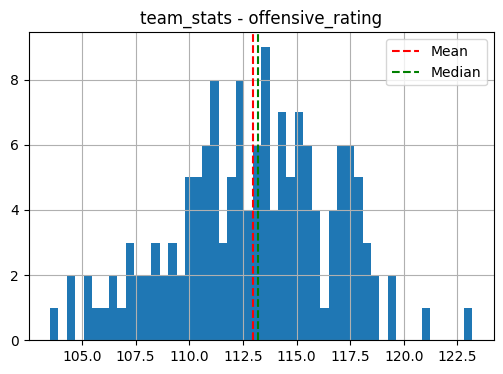

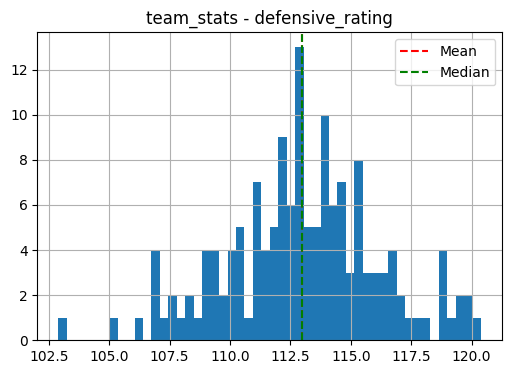

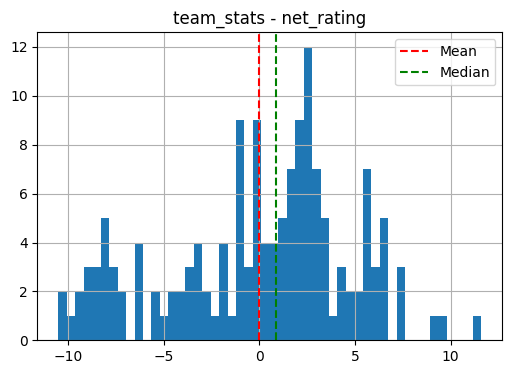

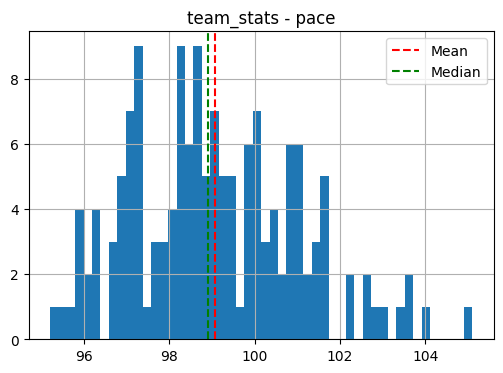

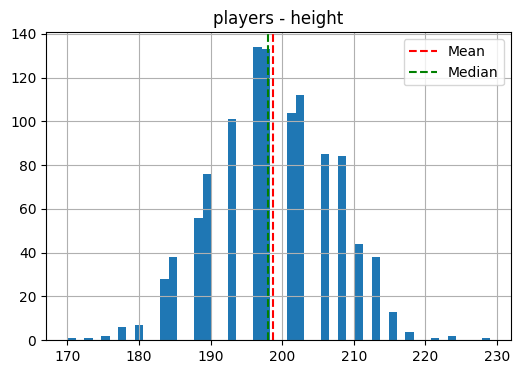

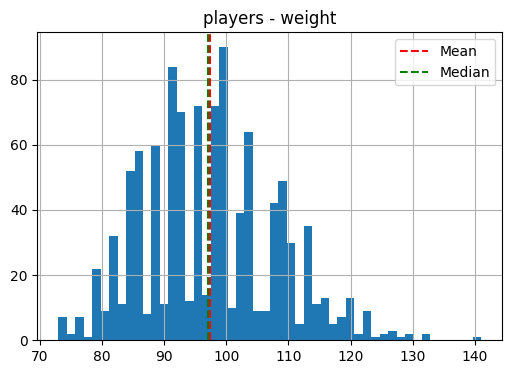

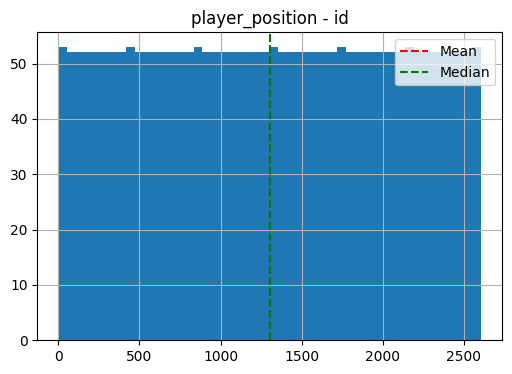

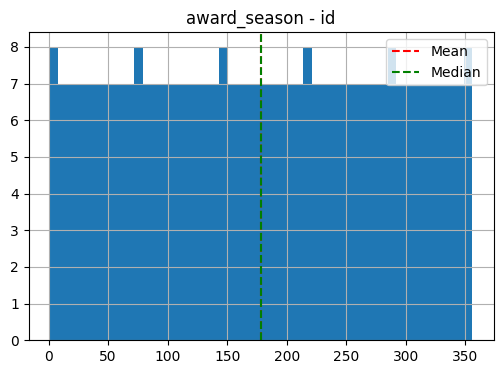

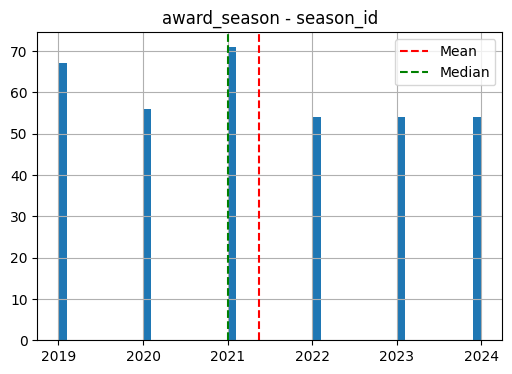

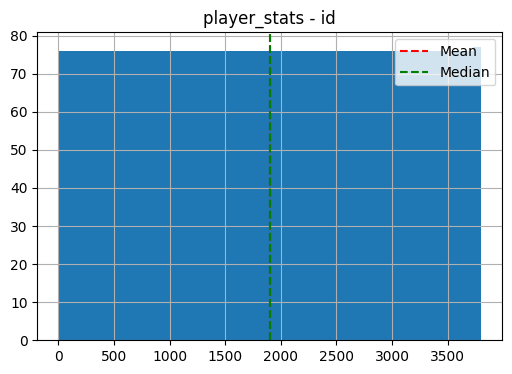

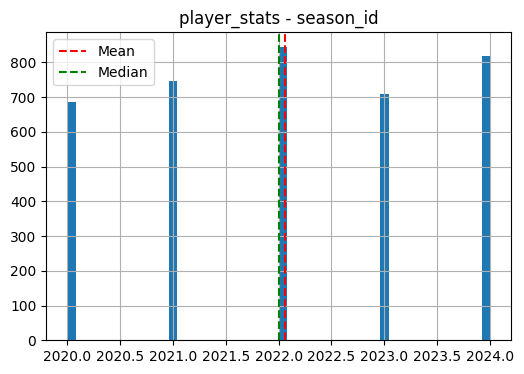

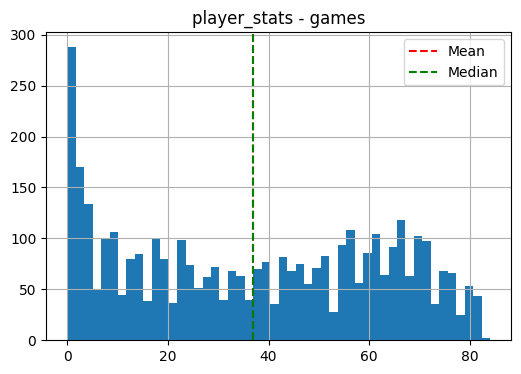

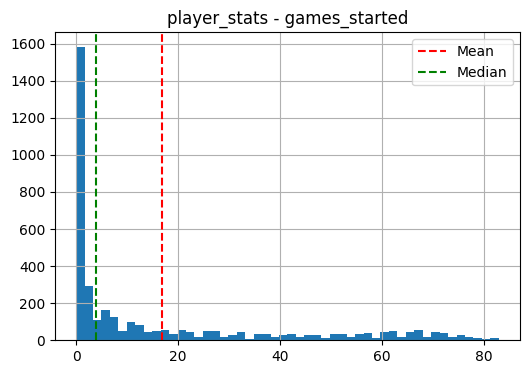

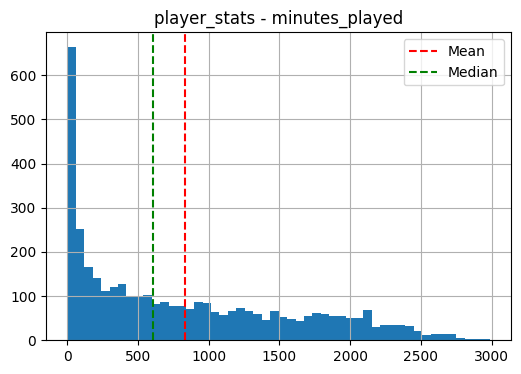

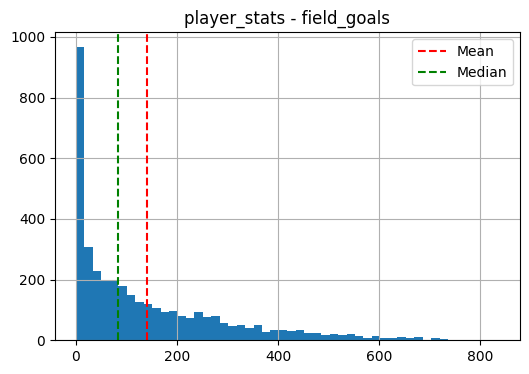

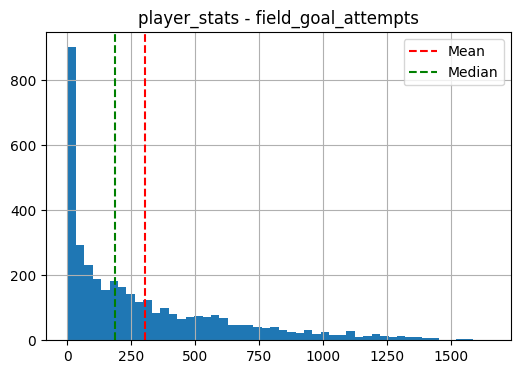

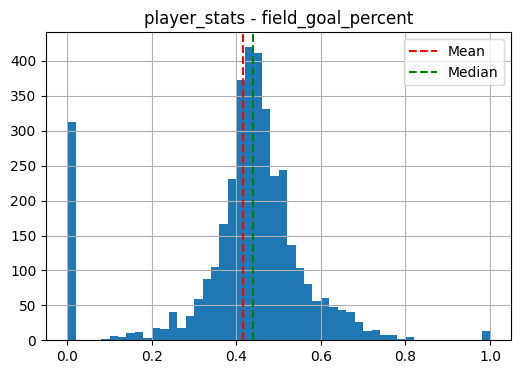

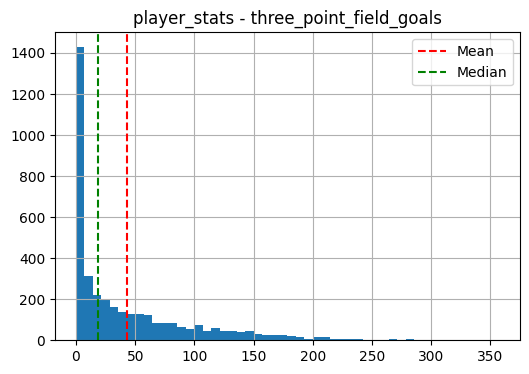

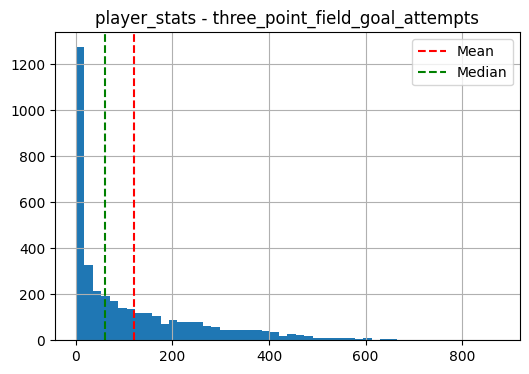

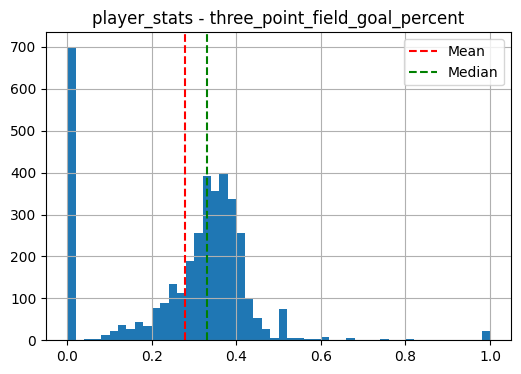

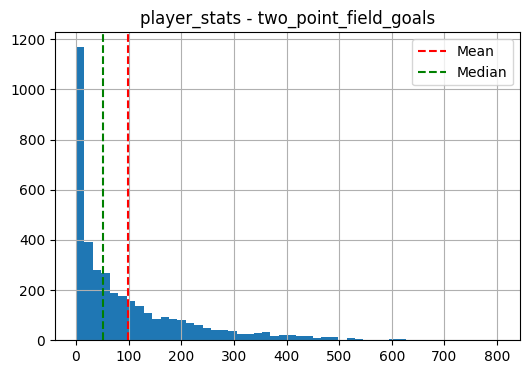

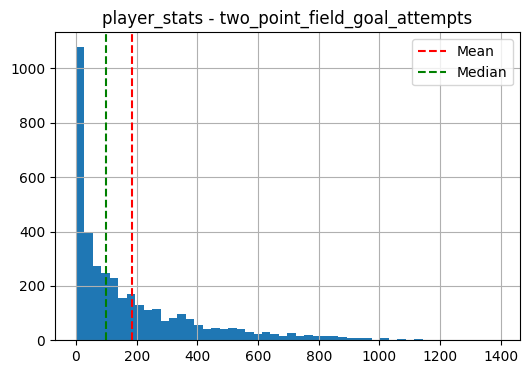

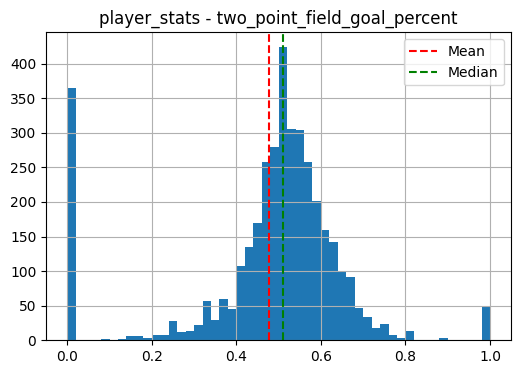

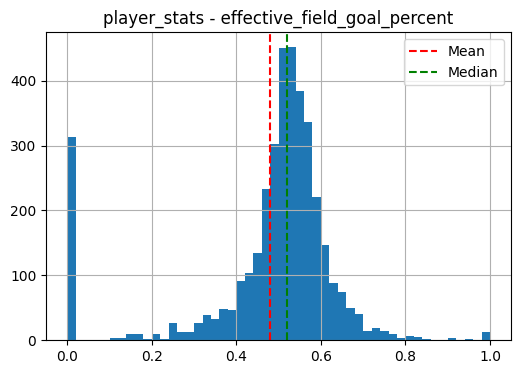

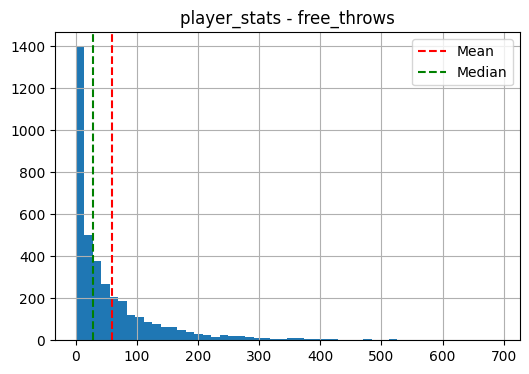

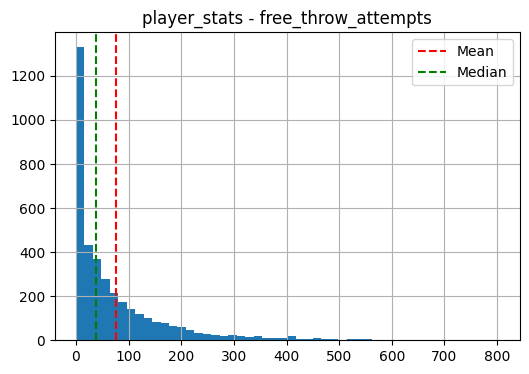

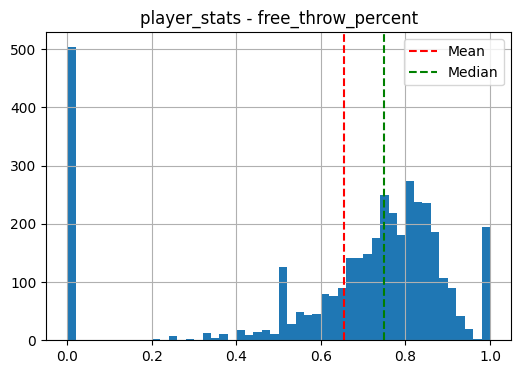

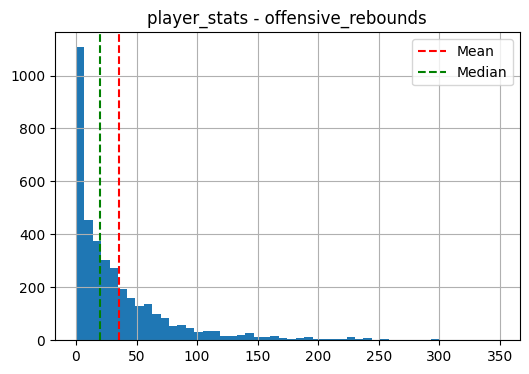

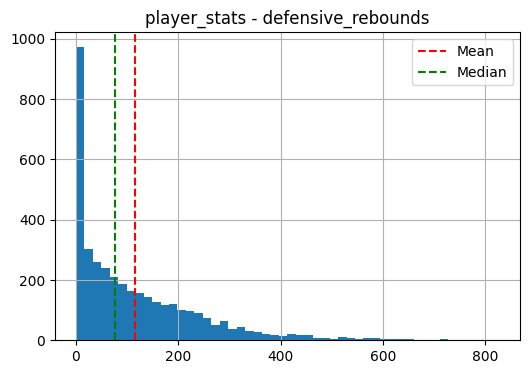

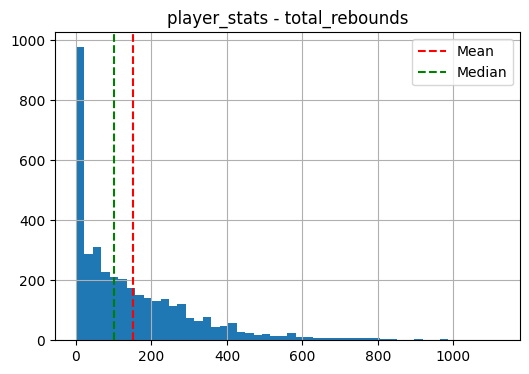

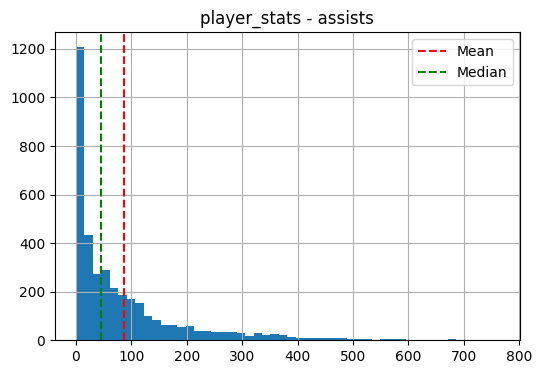

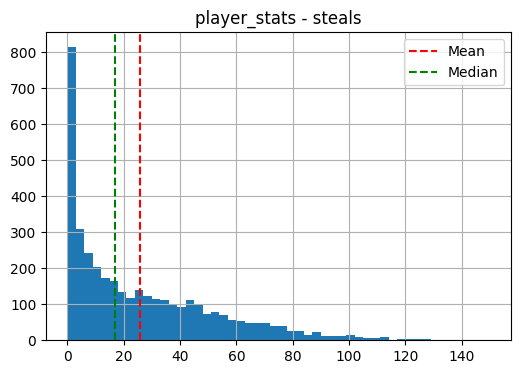

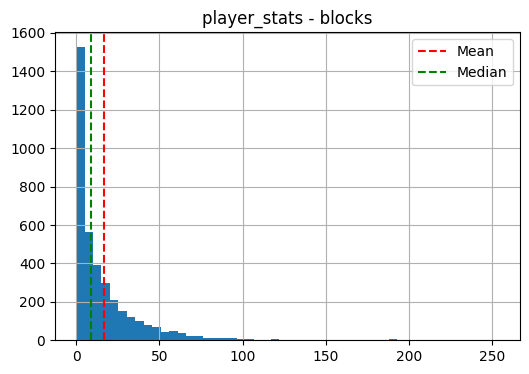

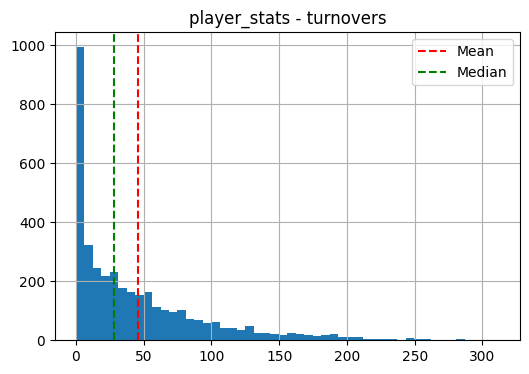

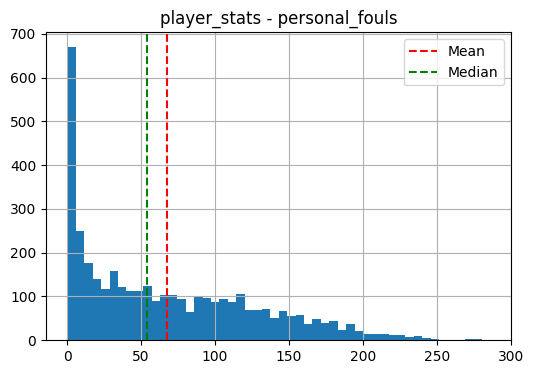

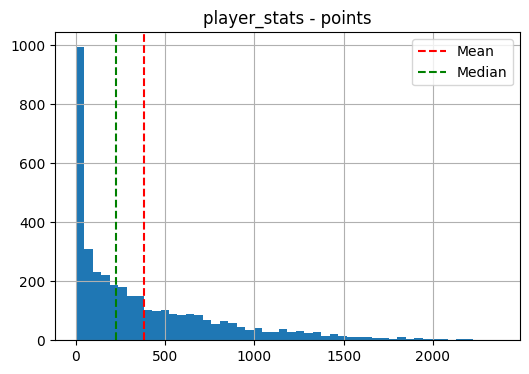

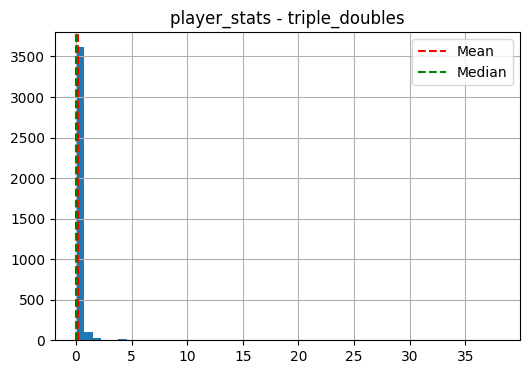

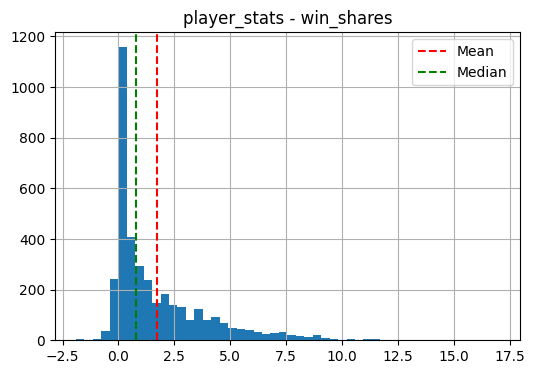

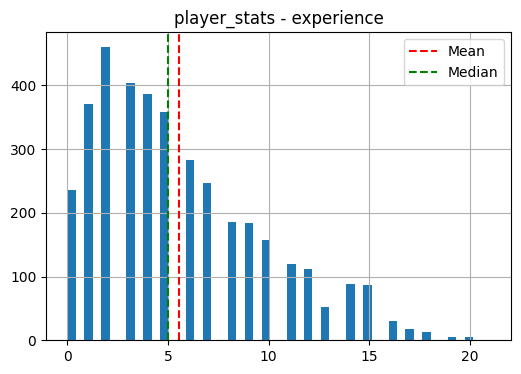

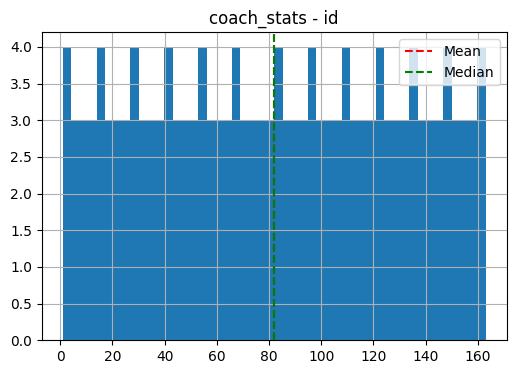

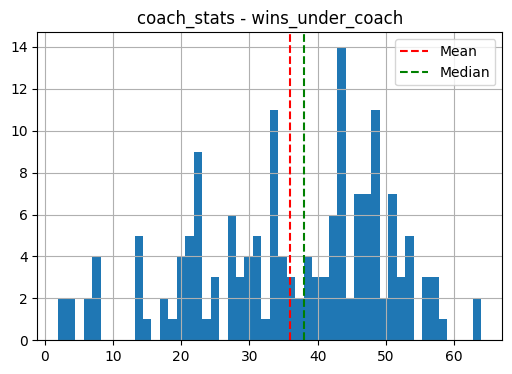

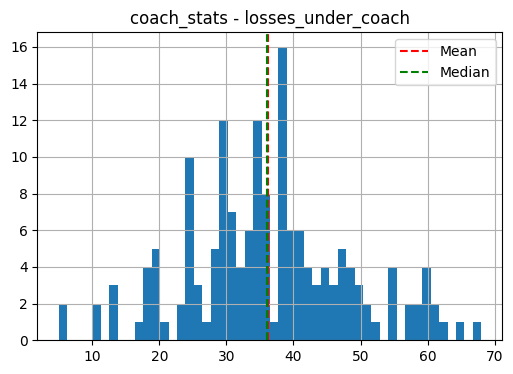

In [6]:
for name, df in dfs.items():
    plot_numeric_distributions(df, name)

In [7]:
def cleaning_dataframe(df, name, pk_cols, replacement="median", threshold=0.05):
   df_cleaned = df.copy()
    
   if pk_cols:
        df_cleaned = df_cleaned.drop_duplicates(subset=pk_cols)
    
   total_rows = len(df_cleaned)
   if total_rows == 0:
        return df_cleaned
        
   numeric_cols = []

   for col in df_cleaned.columns:
      dtype_name = df_cleaned[col].dtype.name

      if 'int' in dtype_name or 'float' in dtype_name:
         numeric_cols.append(col)
    
   for col in df_cleaned.columns:
        null_count = df_cleaned[col].isnull().sum()
        if null_count == 0:
            continue
            
        null_ratio = null_count / total_rows
        
        if null_ratio <= threshold:
            df_cleaned = df_cleaned.dropna(subset=[col])
        else:
            if col in numeric_cols:
                if replacement == "mean":
                    fill_value = df_cleaned[col].mean()
                elif replacement == "median":
                    fill_value = df_cleaned[col].median()
                else:
                    fill_value = 0
                df_cleaned[col] = df_cleaned[col].fillna(fill_value)
            else:
                df_cleaned[col] = df_cleaned[col].fillna("Unknown")
                
   return df_cleaned

In [10]:
dfs_clean = {}

dfs_clean["seasons"] = cleaning_dataframe(dfs["seasons"], "seasons", ["season_id"])
dfs_clean["teams"] = cleaning_dataframe(dfs["teams"], "teams", ["team_id"])
dfs_clean["players"] = cleaning_dataframe(dfs["players"], "players", ["player_id"] , "mean")
dfs_clean["player_position"] = cleaning_dataframe(dfs["player_position"], "player_position", ["id"] , "mean")
dfs_clean["coaches"] = cleaning_dataframe(dfs["coaches"], "coaches", ["coach_id"])
dfs_clean["awards"] = cleaning_dataframe(dfs["awards"], "awards", ["award_id"])
dfs_clean["award_season"] = cleaning_dataframe(dfs["award_season"], "award_season", ["id"])
dfs_clean["player_stats"] = cleaning_dataframe(dfs["player_stats"], "player_stats", pk_cols=["id"])
dfs_clean["coach_stats"] = cleaning_dataframe(dfs["coach_stats"], "coach_stats", ["id"])
dfs_clean["team_stats"] = cleaning_dataframe(dfs["team_stats"], "team_stats", ["season_id", "team_id"])

In [11]:
def check_normality(data, alpha=0.05):
     if len(data) < 8:
        return False  

     stat, p_value = normaltest(data)

     return p_value > alpha

1.Question 1
1.1_Compare the height distribution of players on the Michael Jordan Trophy list with that of the season's top 50 players, based on statistics from the 2019–2020 season through the end of the 2023–2024 season.

In [12]:
#SQL Query

jordan_trophy = """
SELECT p.name, p.height, 'Jordan Trophy' AS label
FROM players p
JOIN award_season aws ON p.player_id = aws.player_id
JOIN awards a ON aws.award_id = a.award_id
WHERE a.name LIKE '%Michael Jordan Trophy%' 
  AND aws.season_id BETWEEN 2020 AND 2024;
"""

top_50_players = """
WITH ranked_players AS (
    SELECT 
        p.name,
        p.height,
        ps.season_id,
        ps.win_shares,
        RANK() OVER(
            PARTITION BY ps.season_id 
            ORDER BY ps.win_shares DESC
        ) AS rank
    FROM players p
    JOIN player_stats ps 
        ON p.player_id = ps.player_id
    WHERE ps.season_id BETWEEN 2020 AND 2024
)

SELECT
    name,
    height,
    'Top 50' AS label
FROM ranked_players
WHERE rank <= 50;
"""

jordan_trophy_df = pd.read_sql_query(jordan_trophy , conn)
top_50_players_df = pd.read_sql_query(top_50_players , conn)
df_q1 = pd.concat([jordan_trophy_df , top_50_players_df])
df_q1

,name,height,label
0,Giannis Antetokounmpo,211,Jordan Trophy
1,LeBron James,206,Jordan Trophy
2,James Harden,196,Jordan Trophy
3,Luka Dončić,203,Jordan Trophy
4,Kawhi Leonard,198,Jordan Trophy
...,...,...,...
249,Franz Wagner,208,Top 50
250,Clint Capela,208,Top 50
251,Jrue Holiday,193,Top 50
252,Karl-Anthony Towns,213,Top 50


1.2_Visualization


c:\Users\d0nya\AppData\Local\Programs\Python\Python39\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\d0nya\AppData\Local\Programs\Python\Python39\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\d0nya\AppData\Local\Programs\Python\Python39\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\d0nya\AppDat

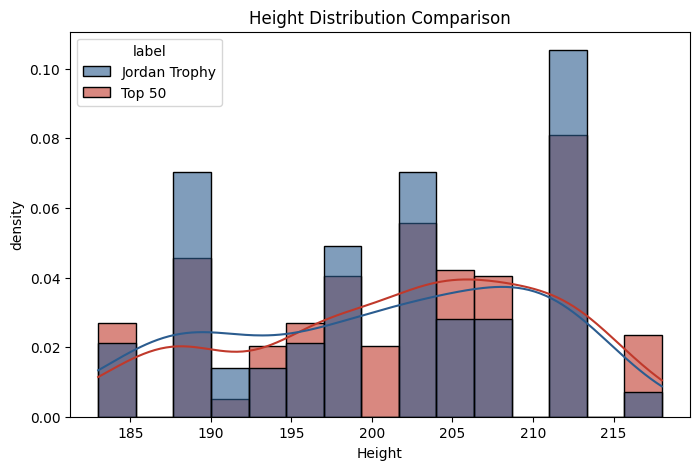

In [13]:
palette = {
    'Jordan Trophy': '#2b5c8f',  
    'Top 50': '#c0392b'        
}

plt.figure(figsize=(8,5))

sns.histplot(
    data=df_q1,
    x="height",
    hue="label",
    kde=True,
    bins=15,
    stat="density",
    alpha=0.6,
    common_norm=False,
    palette=palette
    )

plt.title("Height Distribution Comparison")
plt.xlabel("Height")
plt.ylabel("density")
plt.show()

2.Question 2 2.1_Compare Experience distribution and height in last two seasons between champion team and 15 best players

In [17]:
last_two_seasons = sorted(dfs_clean["seasons"]["season_id"].unique())[-2:]
print(f"Last Two Seasons: {last_two_seasons}")

comparison_data = []

for season in last_two_seasons:
    season_team_stats = dfs_clean["team_stats"][dfs_clean["team_stats"]["season_id"] == season]
    
    champ_rows = season_team_stats[
        season_team_stats["playoff_result"].astype(str).str.contains("Finals|Champion|1", case=False, na=False)
    ]
    
    if len(champ_rows) > 0:
        champ_id = champ_rows.iloc[0]["team_id"]
    else:
        champ_id = season_team_stats.sort_values(by="wins", ascending=False).iloc[0]["team_id"]

    champ_players_stats = dfs_clean["player_stats"][
        (dfs_clean["player_stats"]["season_id"] == season) & 
        (dfs_clean["player_stats"]["team_id"] == champ_id)
    ]
    
    top15_players_stats = dfs_clean["player_stats"][
        dfs_clean["player_stats"]["season_id"] == season
    ].sort_values(by="points", ascending=False).head(15)

    champ_merged = champ_players_stats.merge(
        dfs_clean["players"][["player_id", "height", "name"]], 
        on="player_id", 
        how="left"
    )
    top15_merged = top15_players_stats.merge(
        dfs_clean["players"][["player_id", "height", "name"]], 
        on="player_id", 
        how="left"
    )
    
    champ_merged["Group"] = "Champion Team"
    champ_merged["Season"] = season
    
    top15_merged["Group"] = "15 Best Players"
    top15_merged["Season"] = season
    
    comparison_data.append(champ_merged)
    comparison_data.append(top15_merged)

df_q2 = pd.concat(comparison_data, ignore_index=True)

df_q2["height"] = pd.to_numeric(df_q2["height"], errors="coerce")
df_q2["experience"] = pd.to_numeric(df_q2["experience"], errors="coerce")
df_q2

Last Two Seasons: [2023, 2024]


,id,season_id,player_id,team_id,games,games_started,minutes_played,field_goals,field_goal_attempts,field_goal_percent,...,turnovers,personal_fouls,points,triple_doubles,win_shares,experience,height,name,Group,Season
0,163,2023,brownja02,BOS,67,67,2405,679,1383,0.491,...,197,172,1784,0,5.0,7,198,Jaylen Brown,Champion Team,2023
1,205,2023,smartma01,BOS,61,61,1957,250,602,0.415,...,143,172,703,0,3.7,9,190,Marcus Smart,Champion Team,2023
2,210,2023,tatumja01,BOS,74,74,2732,727,1559,0.466,...,213,160,2225,1,10.5,6,203,Jayson Tatum,Champion Team,2023
3,243,2023,willigr01,BOS,79,23,2045,216,476,0.454,...,82,192,641,0,4.4,4,201,Grant Williams,Champion Team,2023
4,250,2023,williro04,BOS,35,20,824,127,170,0.747,...,34,68,279,0,3.8,5,206,Robert Williams,Champion Team,2023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62,2322,2024,derozde01,CHI,79,79,2989,650,1355,0.480,...,135,161,1897,0,9.2,14,198,DeMar DeRozan,15 Best Players,2024
63,1475,2024,davisan02,LAL,76,76,2700,713,1283,0.556,...,159,177,1876,2,11.8,11,208,Anthony Davis,15 Best Players,2024
64,2244,2024,bookede01,PHO,68,68,2447,642,1305,0.492,...,178,206,1841,0,9.2,8,196,Devin Booker,15 Best Players,2024
65,1497,2024,jamesle01,LAL,71,71,2504,685,1269,0.540,...,245,78,1822,5,8.5,20,206,LeBron James,15 Best Players,2024


2.2_ Visualization

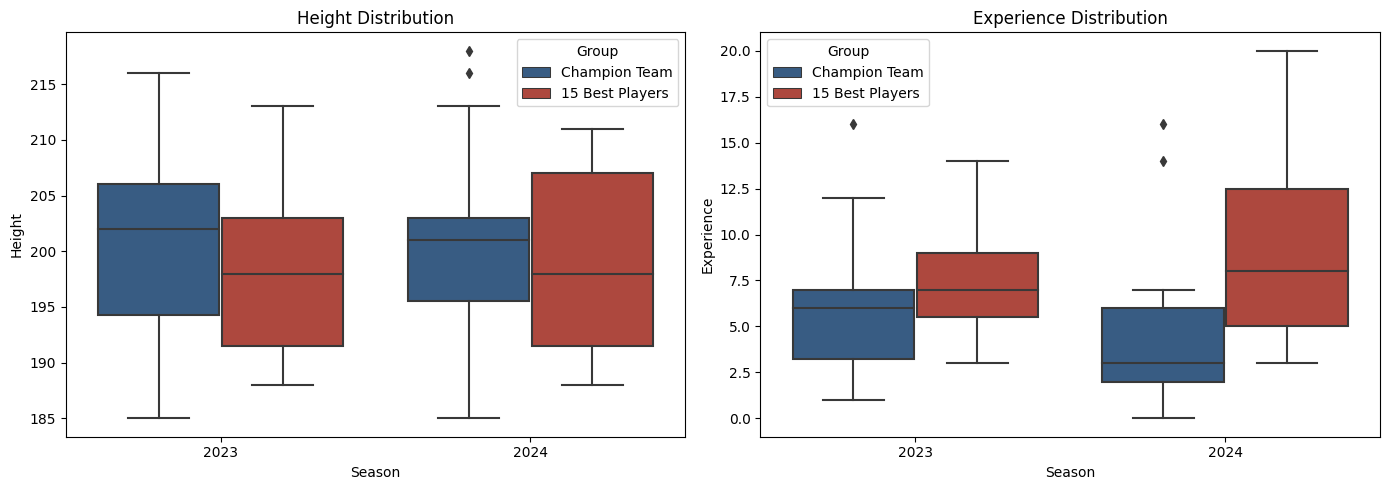

In [19]:
plt.figure(figsize=(14, 5))

#height plot
plt.subplot(1, 2, 1)
sns.boxplot(data=df_q2, x="Season", y="height", hue="Group", palette=["#2b5c8f", "#c0392b"])
plt.title("Height Distribution")
plt.xlabel("Season")
plt.ylabel("Height")

#experience plot
plt.subplot(1, 2, 2)
sns.boxplot(data=df_q2, x="Season", y="experience", hue="Group", palette=["#2b5c8f", "#c0392b"])
plt.title("Experience Distribution")
plt.xlabel("Season")
plt.ylabel("Experience")

plt.tight_layout()
plt.show()

In [20]:
print(df_q2.groupby(["Season", "Group"])[["height", "experience"]].agg(["mean", "median"]))

                            height        experience       
                              mean median       mean median
Season Group                                               
2023   15 Best Players  198.400000  198.0   7.333333    7.0
       Champion Team    200.277778  202.0   6.166667    6.0
2024   15 Best Players  199.466667  198.0   8.866667    8.0
       Champion Team    200.578947  201.0   4.684211    3.0


3.Question 3
3.1_A recommendation of three players for the Point Guard (PG) position, based on the highest number of appearances in the Michael Jordan Trophy.


In [49]:
#SQL Query
point_guards_jordan = """
SELECT p.player_id, p.name, COUNT(aws.id) AS trophy_count
FROM players p
JOIN player_position pp ON p.player_id = pp.player_id
JOIN award_season aws ON p.player_id = aws.player_id
JOIN awards a ON aws.award_id = a.award_id
WHERE pp.position LIKE '%Point Guard%'
  AND a.name LIKE '%Michael Jordan Trophy%'
  AND aws.season_id BETWEEN 2020 AND 2024
GROUP BY p.player_id, p.name
ORDER BY trophy_count DESC, p.name ASC
LIMIT 3;
"""
point_guards_jordan_df = pd.read_sql_query(point_guards_jordan , conn)
point_guards_jordan_df

,player_id,name,trophy_count
0,doncilu01,Luka Dončić,5
1,paulch01,Chris Paul,3
2,jamesle01,LeBron James,3


3.2_Visualization

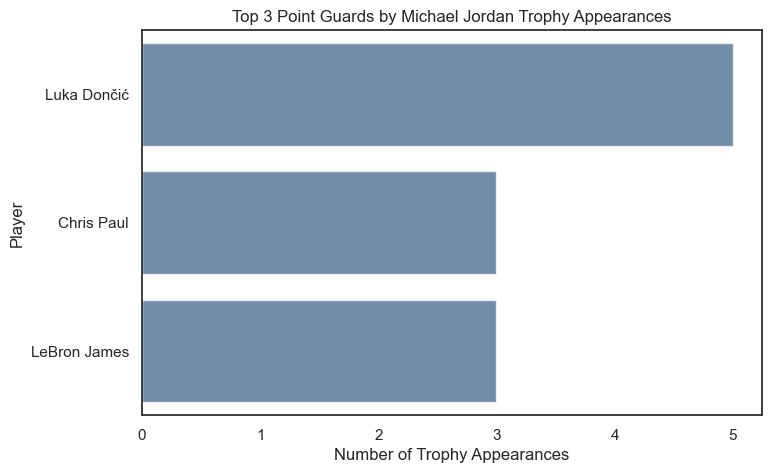

In [67]:
plt.figure(figsize=(8,5))

sns.barplot(
    data= point_guards_jordan_df,
    y ="name" , 
    x ="trophy_count",
    color='#2b5c8f',
    alpha = 0.7
)

plt.title("Top 3 Point Guards by Michael Jordan Trophy Appearances")
plt.xlabel("Number of Trophy Appearances")
plt.ylabel("Player")

plt.show()


4.Q 4


In [70]:
#SQL Query

hypothesis_1 = """
WITH RankedSeason AS (
    SELECT 
        p.player_id,
        p.height,
        p.weight,
        ps.season_id,
        CAST(p.height AS REAL) / p.weight AS agility,
        ROW_NUMBER() OVER (
            PARTITION BY ps.season_id 
            ORDER BY ps.win_shares DESC
        ) AS rank
    FROM players p
    JOIN player_stats ps 
        ON p.player_id = ps.player_id
)

SELECT 
    season_id,
    agility,
    CASE 
        WHEN season_id IN (2021, 2022) THEN 'Past_Group'
        WHEN season_id IN (2023, 2024) THEN 'Recent_Group'
    END AS period
FROM RankedSeason
WHERE rank <= 20
  AND season_id IN (2021, 2022, 2023, 2024);
"""

hypothesis_2 = """
WITH DataWithAge AS (
    SELECT 
        ps.season_id,
        ps.experience,
        (ps.season_id - CAST(STRFTIME('%Y', p.birthdate) AS INTEGER)) AS age
    FROM players p
    JOIN player_stats ps 
        ON p.player_id = ps.player_id
    JOIN seasons s 
        ON ps.season_id = s.season_id
    WHERE ps.team_id = s.champion_id
      AND ps.season_id IN (2021, 2022, 2023, 2024)
      AND ps.games > 0
)

SELECT 
    season_id,
    experience,
    age,
    CAST(experience AS REAL) / age AS innate_ability,
    CASE 
        WHEN season_id IN (2021, 2022) THEN 'Past_Group'
        WHEN season_id IN (2023, 2024) THEN 'Recent_Group'
    END AS period
FROM DataWithAge;
"""

h1_df = pd.read_sql_query( hypothesis_1,conn)
h2_df = pd.read_sql_query( hypothesis_2,conn)

In [75]:
def hypothesis_test(df,value_col,group_col,group1,group2,alpha=0.05):
    data1 = df[df[group_col] == group1][value_col].dropna()
    data2 = df[df[group_col] == group2][value_col].dropna()


    normal1 = check_normality(data1, alpha)
    normal2 = check_normality(data2, alpha)


    if normal1 and normal2:

        test_name = "Independent T-test"

        stat, p_value = ttest_ind(
            data1,
            data2,
            equal_var=False,
            alternative="greater"
        )

    else:

        test_name = "Mann Whitney U"

        stat, p_value = mannwhitneyu(
            data1,
            data2,
            alternative="greater"
        )


    result = pd.DataFrame({
        "Variable": [value_col],
        "Test": [test_name],
        "Group1": [group1],
        "Group2": [group2],
        "Normal_Group1": [normal1],
        "Normal_Group2": [normal2],
        "Statistic": [stat],
        "P_Value": [p_value],
        "Reject_H0": [p_value < alpha]
    })

    return result

     

4.1.1_hypothesis 1
The average agility of the top 20 players in recent seasons has increased compared to previous seasons.
H0​:μRecent​≤μPast​
H1​:μRecent​>μPast​

In [76]:
h1_result = hypothesis_test(
    df=h1_df,
    value_col="agility",
    group_col="period",
    group1="Past_Group",
    group2="Recent_Group"
)

h1_result

,Variable,Test,Group1,Group2,Normal_Group1,Normal_Group2,Statistic,P_Value,Reject_H0
0,agility,Mann Whitney U,Past_Group,Recent_Group,False,True,586.0,0.971814,False


4.1.2_Visualization

4.2.1_hypothesis 2
The innate ability of the champion team's players has increased over the last two seasons compared to the two seasons prior.
H0​:μRecent​≤μPast​
H1​:μRecent​>μPast​